In [141]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
import numpy as np
import json

COLOR_MALE = "#66b3ff"
COLOR_FEMALE = "#ff9999"
RESOLUTION = 300
DESCRIPTION_FONTSIZE = 20

with open('categorical_data.json', 'r') as f:
    data_mappings = json.load(f)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

ibm_df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

for column_name, mapping_info in data_mappings.items():
    # Check if the column exists in our DataFrame
    if column_name in ibm_df.columns:
        print(f"\n... Mapping column: {column_name}")
        # Get the specific value map (e.g., {'1': 'Low', '2': 'Medium', ...})
        value_map = mapping_info['values']
        
        # Convert the column to string and apply the map
        ibm_df[column_name] = ibm_df[column_name].astype(str).map(value_map)

print(ibm_df.head())


... Mapping column: Education

... Mapping column: JobLevel

... Mapping column: EnvironmentSatisfaction

... Mapping column: JobInvolvement

... Mapping column: JobSatisfaction

... Mapping column: PerformanceRating

... Mapping column: RelationshipSatisfaction

... Mapping column: WorkLifeBalance
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome          Education EducationField  EmployeeCount  \
0                 1        2 - College  Life Sciences              1   
1                 8  1 - Below College  Life Sciences              1   
2                 2        2 - College

# Slide 2

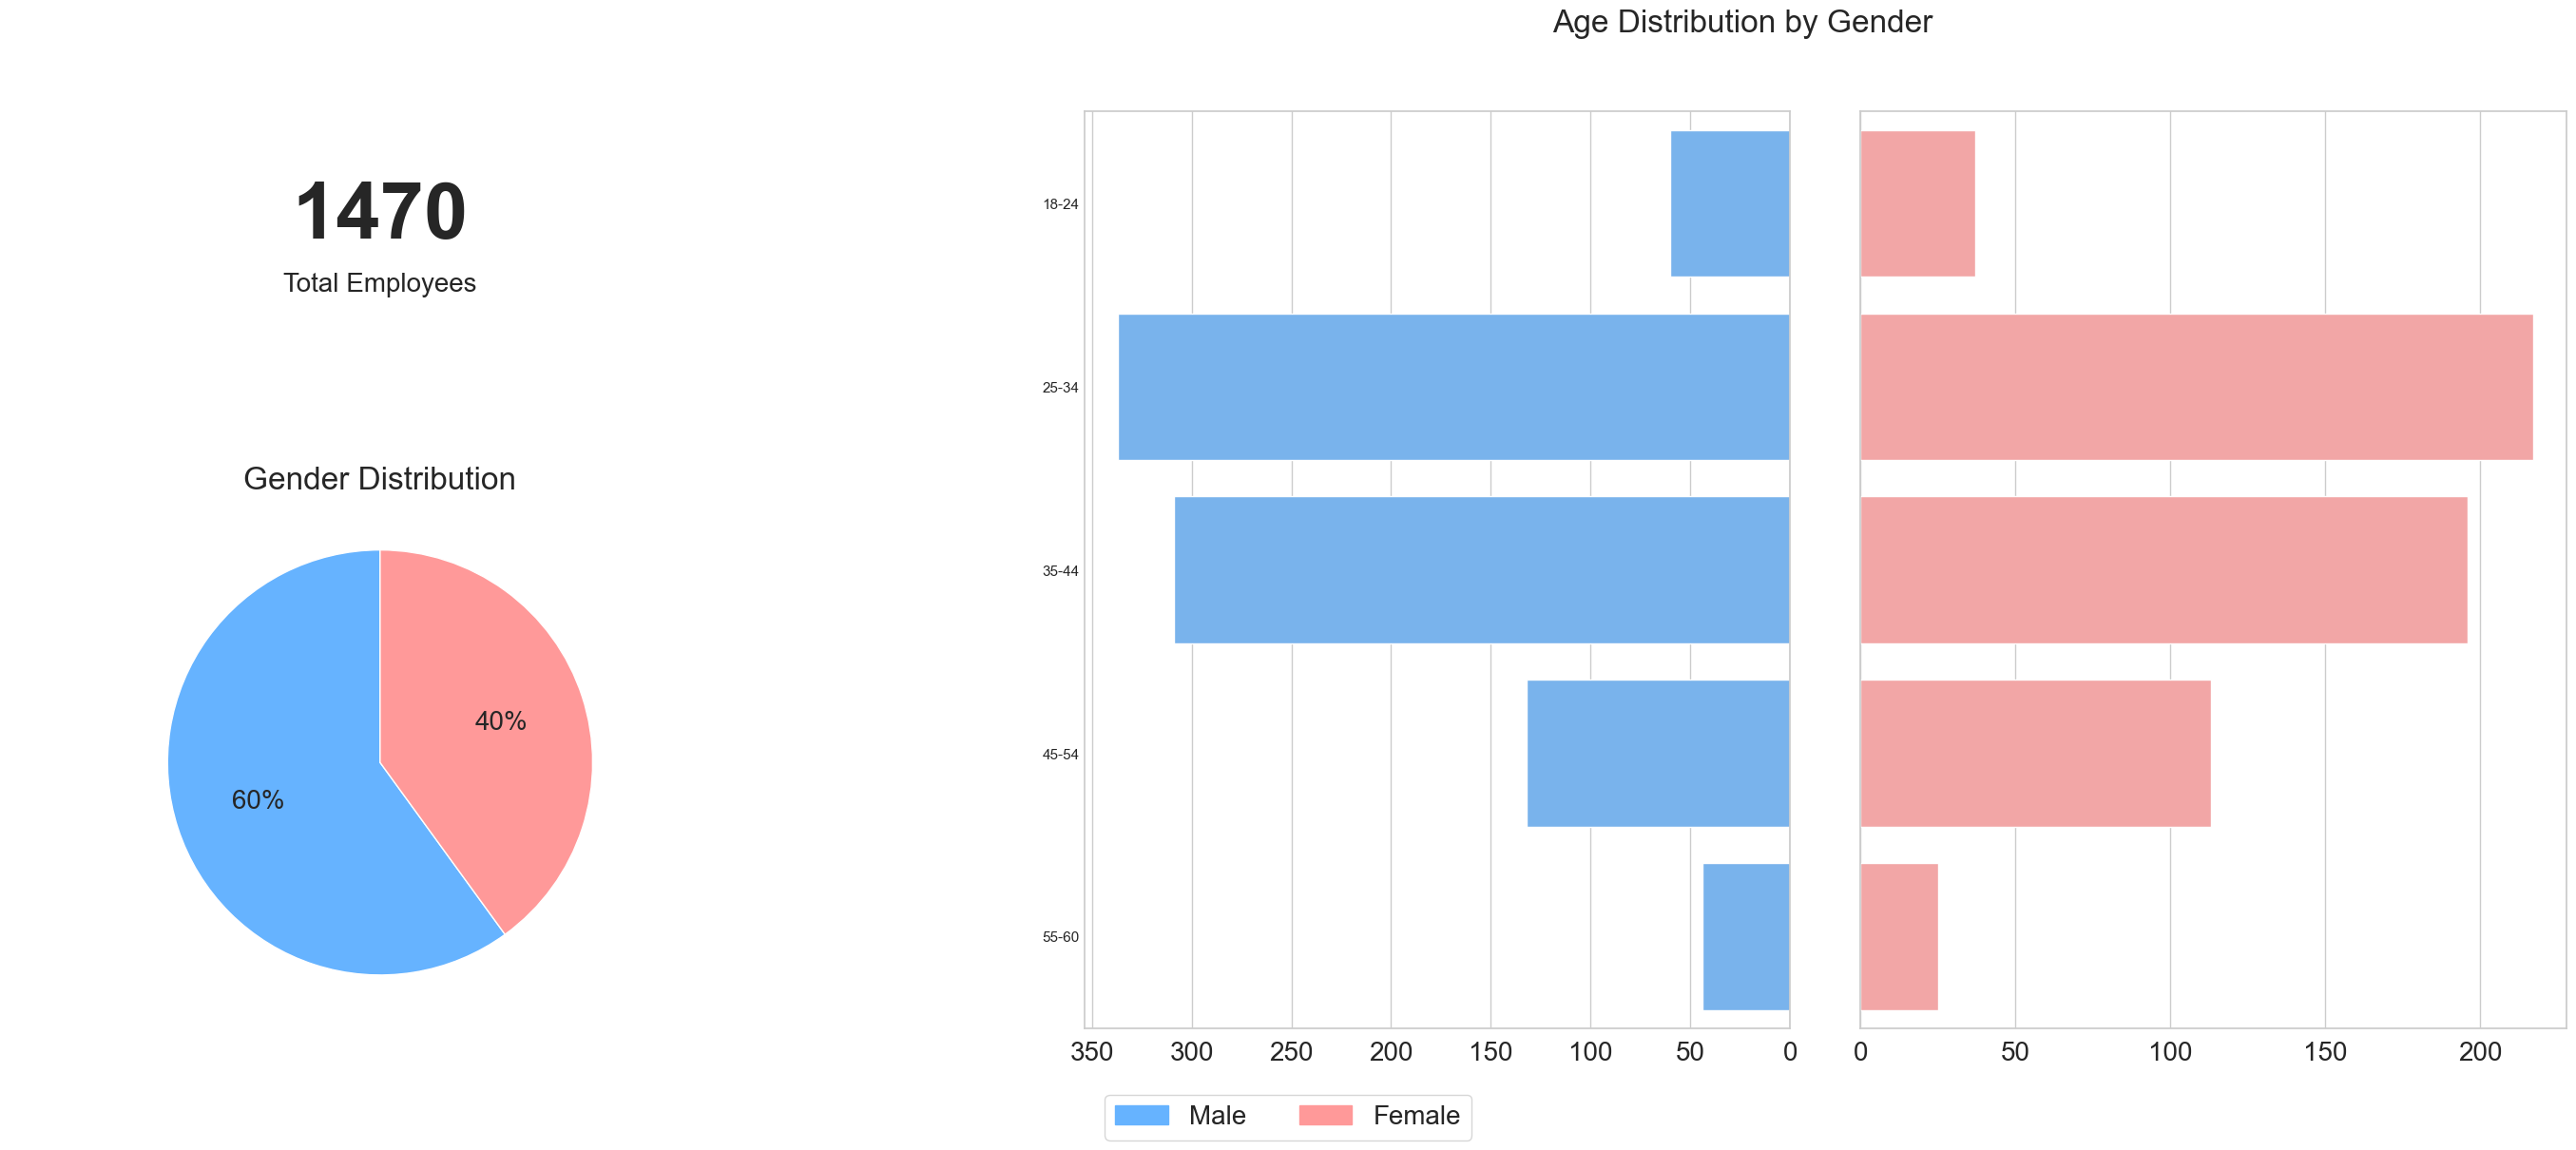

In [146]:
fig = plt.figure(figsize=(29.89, 13.21))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2], height_ratios=[1, 2], figure=fig)

# Top Left - Total Employees
ax_text = fig.add_subplot(gs[0, 0])
total_employees = len(ibm_df)
ax_text.text(0.5, 0.6, f"{total_employees}", ha='center', va='center', fontsize=60, fontweight='bold')
ax_text.text(0.5, 0.35, "Total Employees", ha='center', va='center', fontsize=DESCRIPTION_FONTSIZE)
ax_text.axis('off')

# Bottom Left - Pie Chart
ax_pie = fig.add_subplot(gs[1, 0])
gender_counts = ibm_df['Gender'].value_counts()
ax_pie.pie(gender_counts, labels=None, autopct='%1.0f%%', startangle=90,
           colors=[COLOR_MALE, COLOR_FEMALE], textprops={'fontsize': DESCRIPTION_FONTSIZE})
ax_pie.set_title('Gender Distribution', fontsize=DESCRIPTION_FONTSIZE+4)

# Right Side - Population Pyramid
pyramid_gs = gs[:, 1].subgridspec(1, 2, wspace=0.1)
ax_male = fig.add_subplot(pyramid_gs[0, 0])
ax_female = fig.add_subplot(pyramid_gs[0, 1])

# Prepare data for the pyramid
bins = [18, 25, 35, 45, 55, 61]
labels = ['18-24', '25-34', '35-44', '45-54', '55-60']
ibm_df['AgeGroup'] = pd.cut(ibm_df['Age'], bins=bins, labels=labels, right=False)
male_counts = ibm_df[ibm_df['Gender'] == 'Male']['AgeGroup'].value_counts().sort_index()
female_counts = ibm_df[ibm_df['Gender'] == 'Female']['AgeGroup'].value_counts().sort_index()

# Plot Male data using seaborn
sns.barplot(y=male_counts.index, x=-male_counts.values, color=COLOR_MALE, ax=ax_male, orient='h')
ax_male.set_title('')
ax_male.set_xlabel('')
ax_male.set_ylabel('')
ax_male.tick_params(axis='y', length=0) # Hide y-axis ticks
ax_male.tick_params(axis='x', labelsize=DESCRIPTION_FONTSIZE)
# Format x-axis to be positive
ax_male.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{abs(int(x))}'))

# Plot Female data using seaborn
sns.barplot(y=female_counts.index, x=female_counts.values, color=COLOR_FEMALE, ax=ax_female, orient='h')
ax_female.set_title('')
ax_female.set_xlabel('')
ax_female.set_ylabel('')
ax_female.set_yticks([]) # Hide y-axis labels
ax_female.tick_params(axis='x', labelsize=DESCRIPTION_FONTSIZE)

# Set shared title for the pyramid
fig.text(0.66, 0.95, 'Age Distribution by Gender', ha='center', va='center', fontsize=DESCRIPTION_FONTSIZE+4)

female_patch = mpatches.Patch(color=COLOR_FEMALE, label='Female')
male_patch = mpatches.Patch(color=COLOR_MALE, label='Male')

fig.legend(handles=[male_patch, female_patch],
           loc='lower center',             # Anchor the legend at its bottom-center
           bbox_to_anchor=(0.5, 0.05),     # Position it at the bottom-center of the figure
           ncol=2,                         # Arrange items in 2 columns (one horizontal line)
           fontsize=DESCRIPTION_FONTSIZE)

# Final Adjustments
plt.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.15, wspace=0.3, hspace=0.3)
plt.savefig('reports/slide2_composite_slide.png', dpi=RESOLUTION)

# Slide 3

['Sales', 'Research & Development', 'Human Resources']
['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']


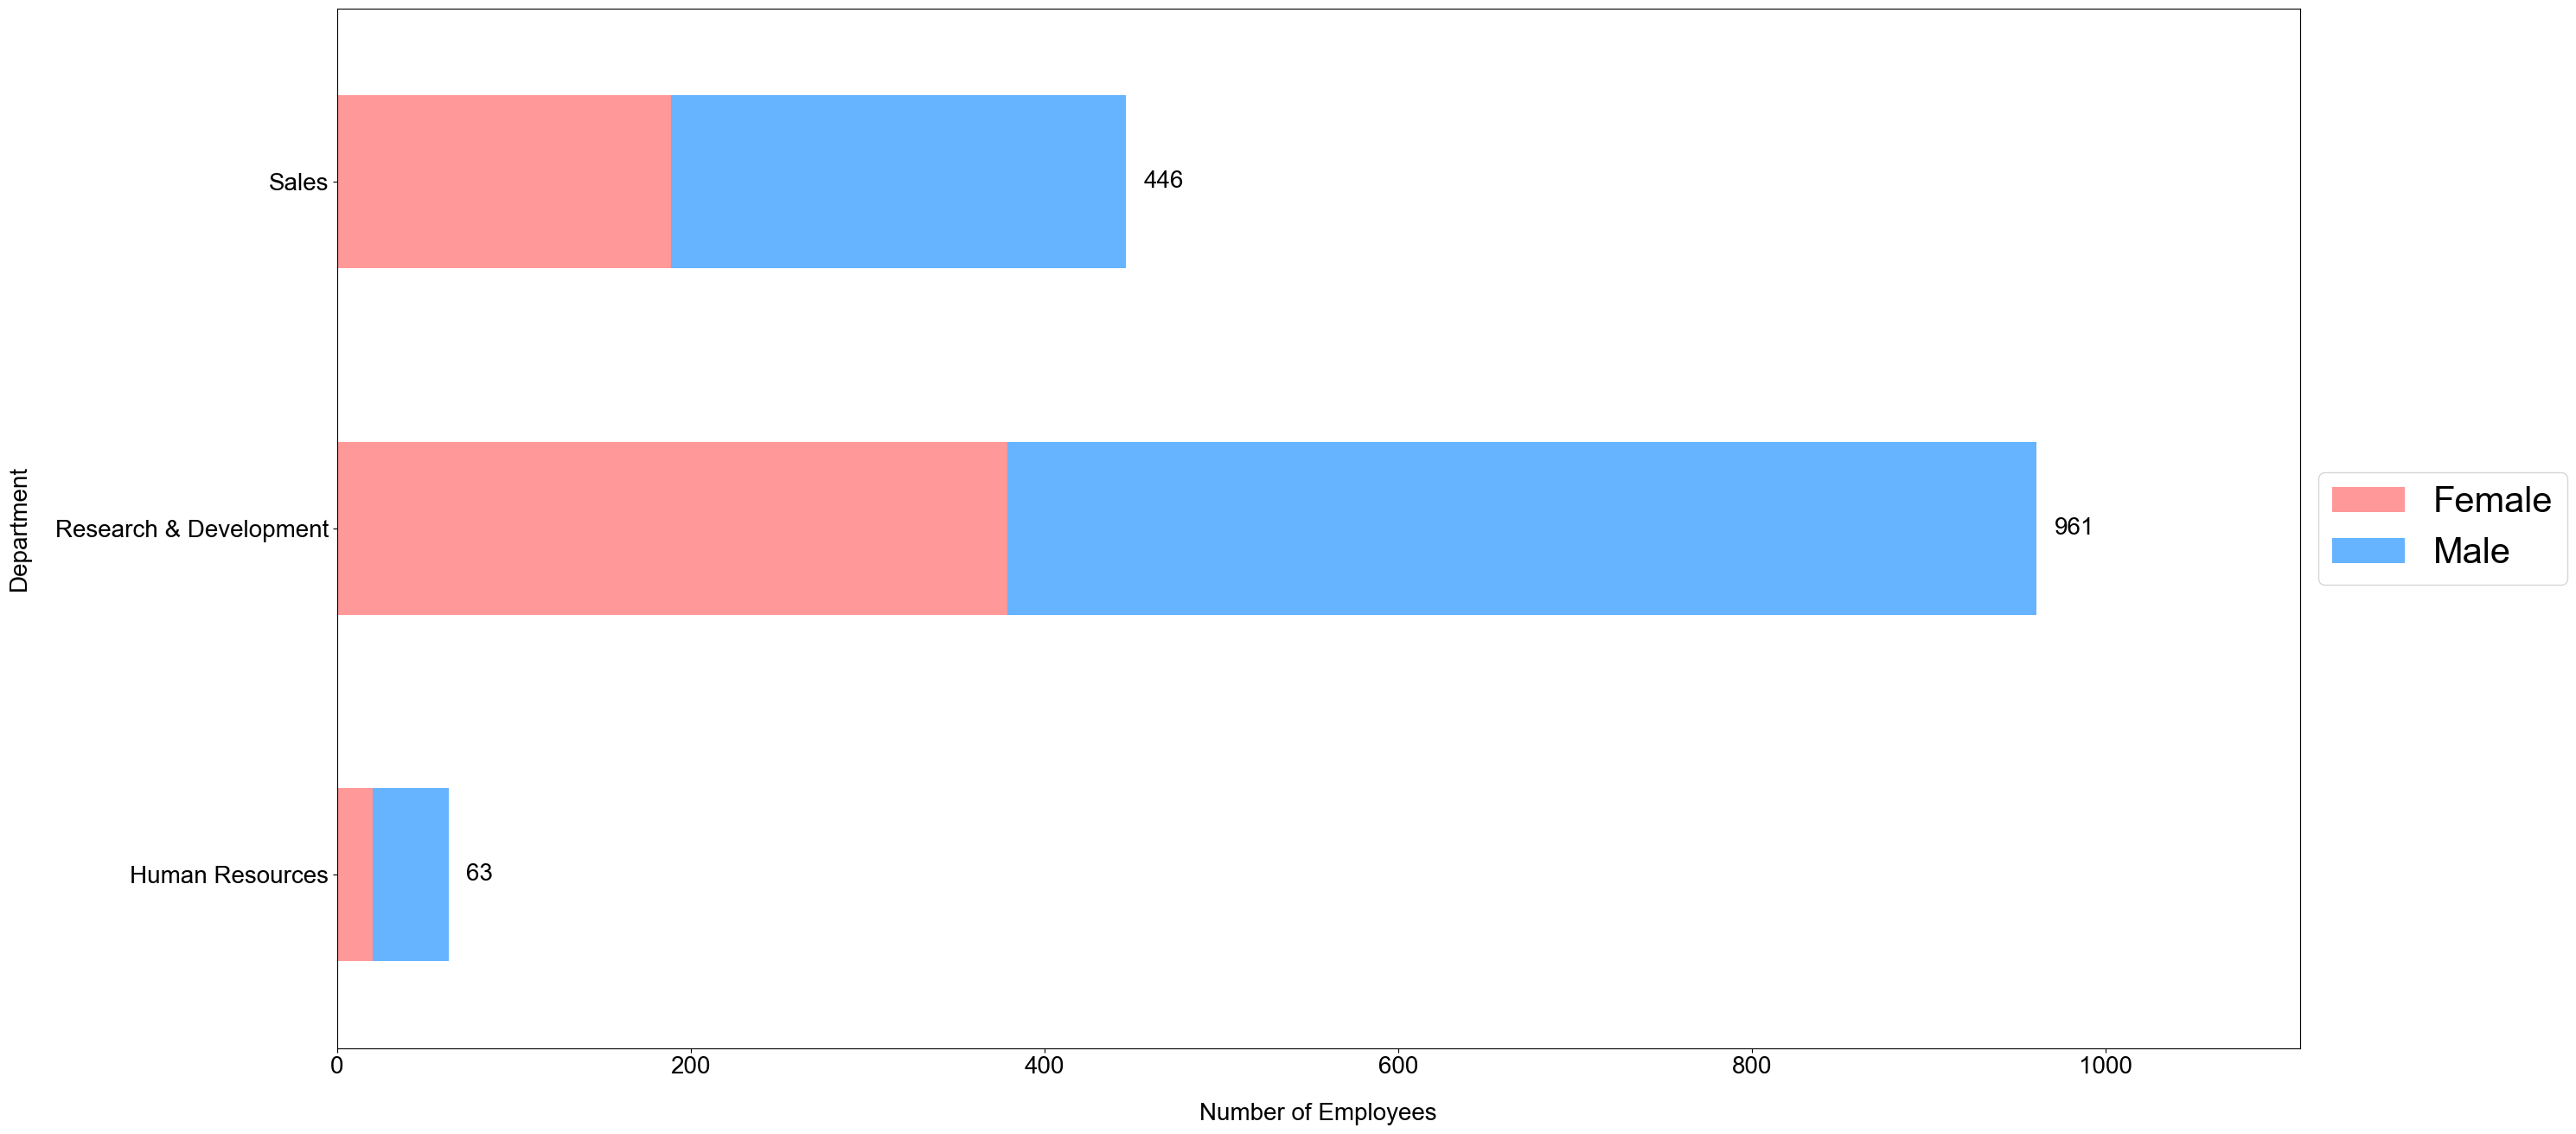

In [103]:
print(str(ibm_df['Department'].unique().tolist()) + "\n" + str(ibm_df['JobRole'].unique().tolist()))

primary_category = 'Department'
stacked_category = 'Gender'

data_to_plot = pd.crosstab(ibm_df[primary_category], ibm_df[stacked_category])

ax = data_to_plot.plot(kind='barh', 
                       stacked=True, 
                       figsize=(29.89, 13.21),
                       color=[COLOR_FEMALE, COLOR_MALE])

ax.set_title('')

ax.set_xlabel('Number of Employees', fontsize=DESCRIPTION_FONTSIZE, labelpad=20) 
ax.set_ylabel('Department', fontsize=DESCRIPTION_FONTSIZE, labelpad=20)

plt.xticks(fontsize=DESCRIPTION_FONTSIZE)
plt.yticks(rotation=0, fontsize=DESCRIPTION_FONTSIZE)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=DESCRIPTION_FONTSIZE+10)

totals = data_to_plot.sum(axis=1)
offset = ax.get_xlim()[1] * 0.01

for i, total in enumerate(totals):
    # The 'total + (total*0.01)' part adds a small gap after the bar.
    ax.text(total + offset, i, str(total),
            va='center', fontsize=DESCRIPTION_FONTSIZE)
    
ax.set_xlim(right=ax.get_xlim()[1] * 1.1)

plt.tight_layout()

plt.savefig('reports/department_stacked_barh.png', dpi=RESOLUTION)

# Slide 4

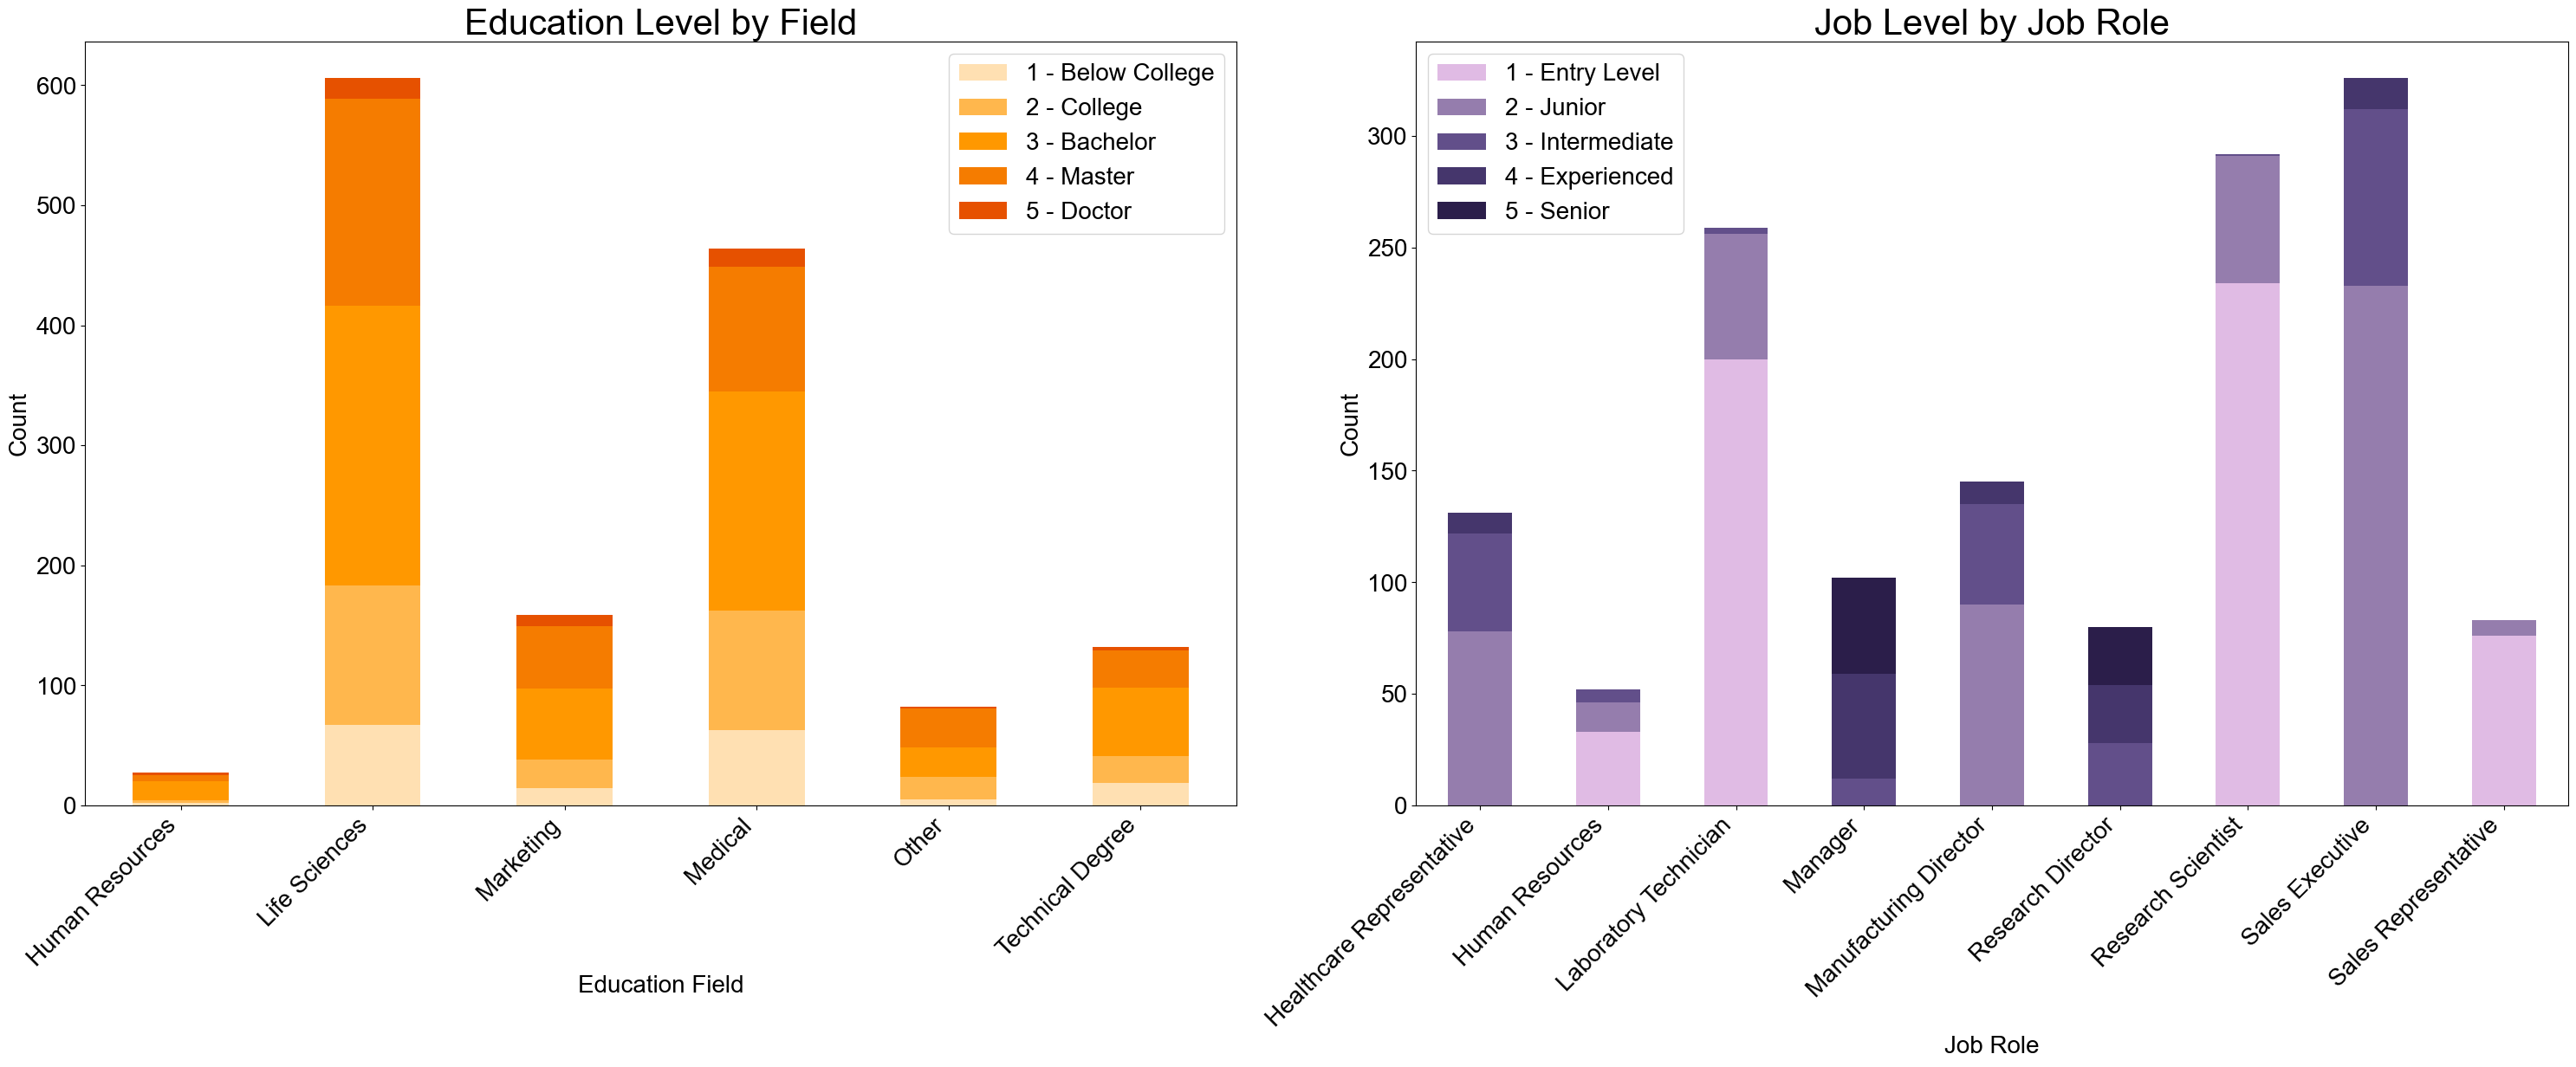

In [109]:
job_level_colors = [
    '#E0BBE4',
    '#957DAD',
    '#624F8A',
    '#45366C',
    '#2B1E4A'
]

education_colors = [
    '#FFE0B2',
    '#FFB74D',
    '#FF9800',
    '#F57C00',
    '#E65100'
]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(29.89, 13.21))

# --- 3. Create the First Column Plot (on axes[0]) ---
plot1_data = pd.crosstab(ibm_df['EducationField'], ibm_df['Education'])
plot1_data.plot(kind='bar', stacked=True, ax=axes[0], color=education_colors, legend=True, fontsize=DESCRIPTION_FONTSIZE)
axes[0].set_title('Education Level by Field', fontsize=DESCRIPTION_FONTSIZE+10)
axes[0].set_xlabel('Education Field', fontsize=DESCRIPTION_FONTSIZE)
axes[0].set_ylabel('Count', fontsize=DESCRIPTION_FONTSIZE)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(fontsize=DESCRIPTION_FONTSIZE)

# --- 4. Create the Second Column Plot (on axes[1]) ---
plot2_data = pd.crosstab(ibm_df['JobRole'], ibm_df['JobLevel'])

plot2_data.plot(kind='bar', stacked=True, ax=axes[1], legend=True, color=job_level_colors, fontsize=DESCRIPTION_FONTSIZE)
axes[1].set_title('Job Level by Job Role', fontsize=DESCRIPTION_FONTSIZE+10)
axes[1].set_xlabel('Job Role', fontsize=DESCRIPTION_FONTSIZE)
axes[1].set_ylabel('Count', fontsize=DESCRIPTION_FONTSIZE)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(fontsize=DESCRIPTION_FONTSIZE)

# 5. Final Adjustments and Saving
plt.tight_layout()
plt.subplots_adjust(top=0.90) # Adjust for the main title
plt.savefig('reports/slide4_two_column_plots.png', dpi=300)

# Slide 5

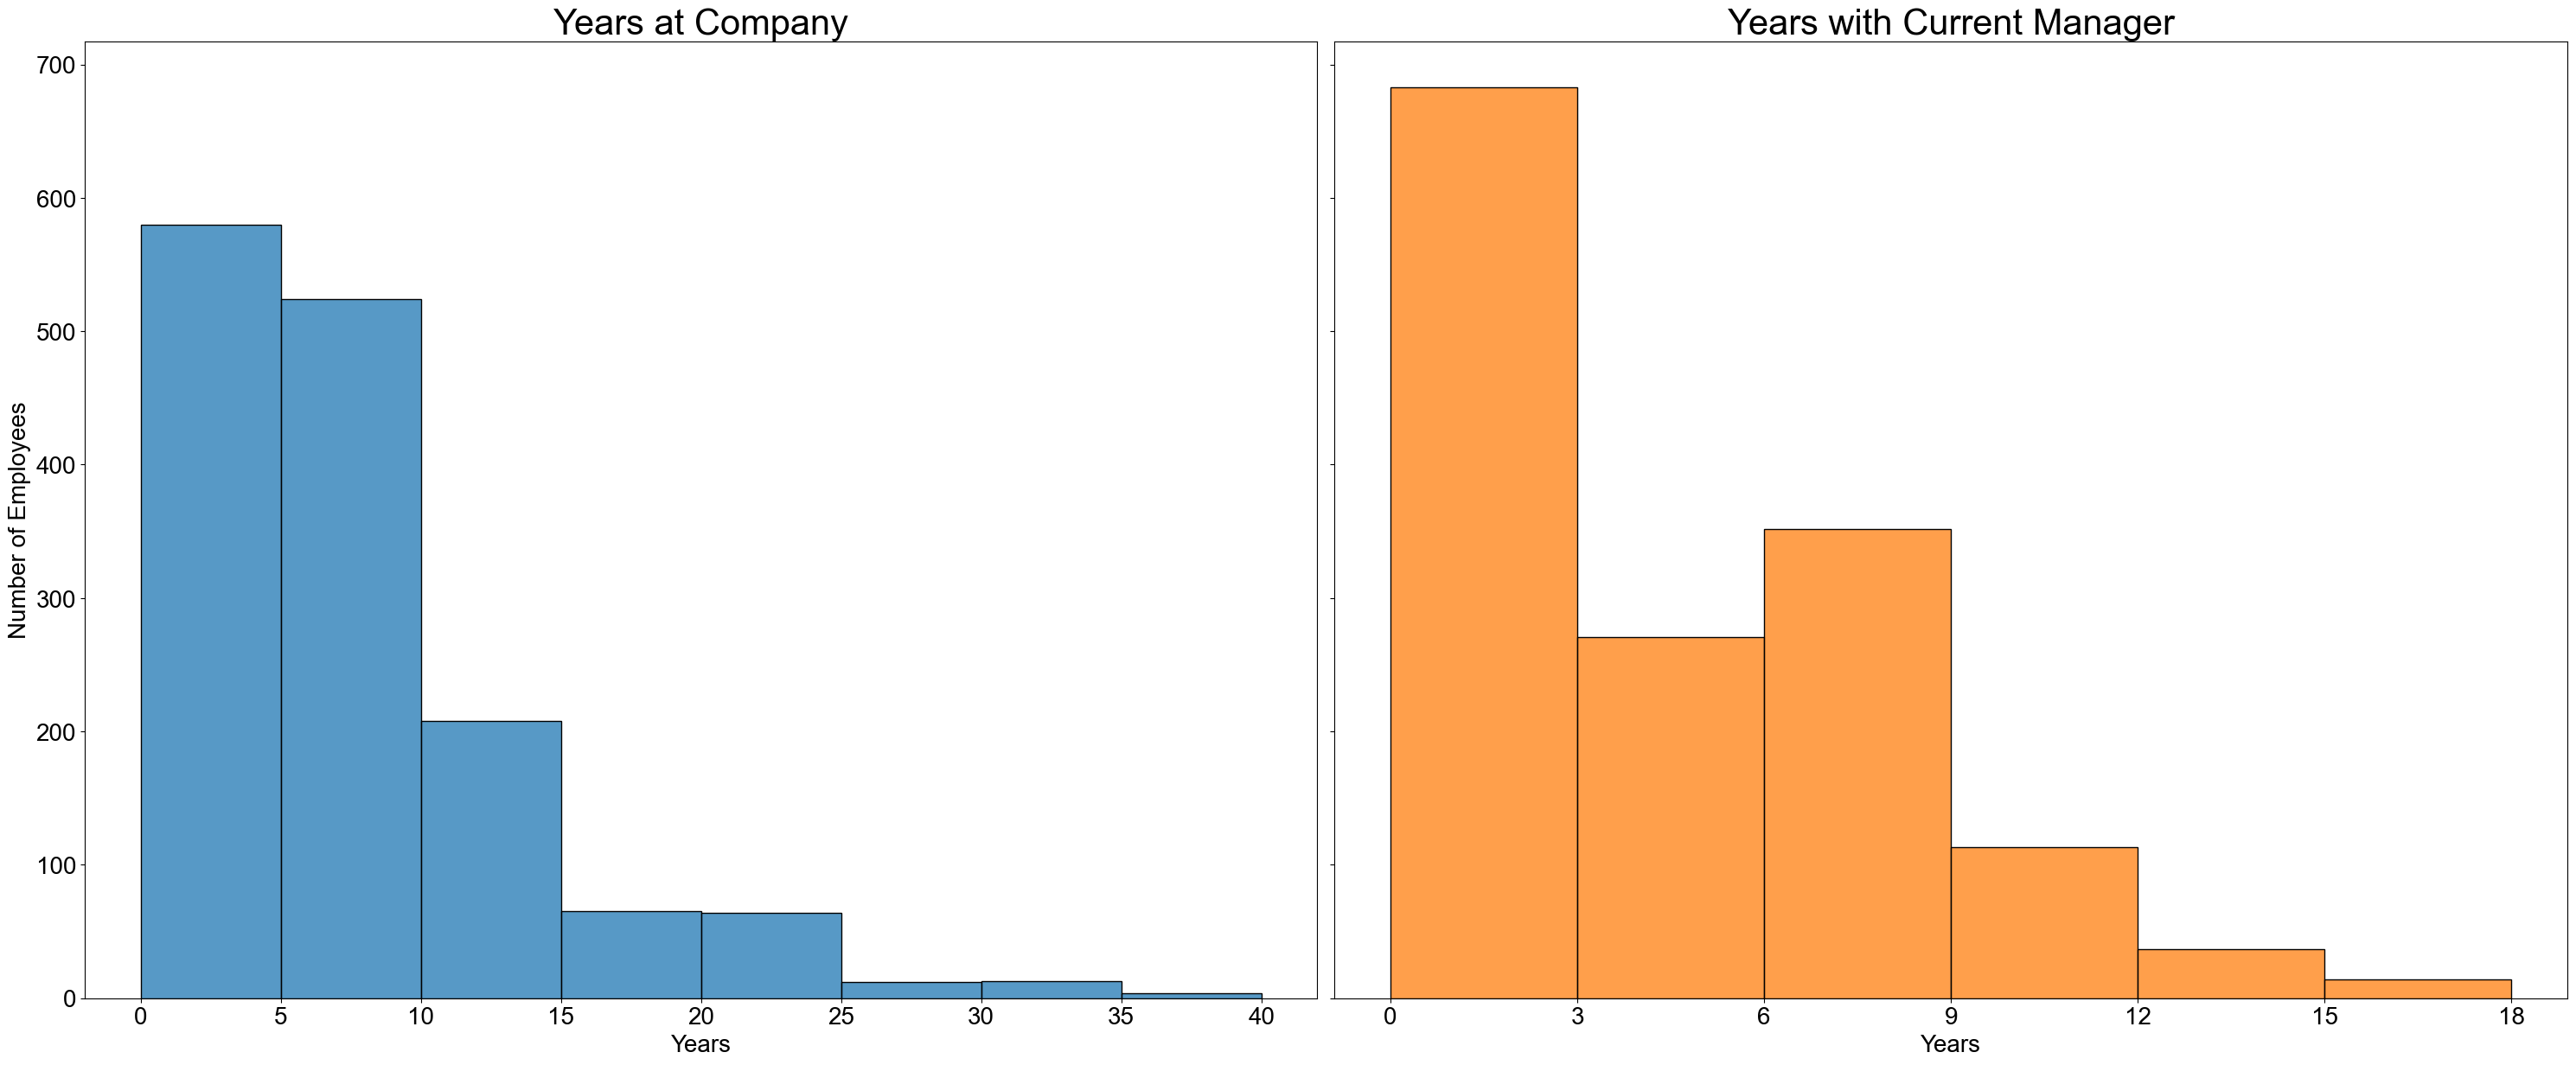

In [132]:
color_at_company = '#1f77b4'
color_with_manager = '#ff7f0e'

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(29.89, 13.21), sharey=True)

sns.histplot(data=ibm_df, x='YearsAtCompany', bins=8, binrange=(0, 40), color=color_at_company, kde=False, ax=axes[0])
axes[0].set_title('Years at Company', fontsize=DESCRIPTION_FONTSIZE+10)
axes[0].set_xlabel('Years', fontsize=DESCRIPTION_FONTSIZE)
axes[0].set_ylabel('Number of Employees', fontsize=DESCRIPTION_FONTSIZE)
axes[0].tick_params(axis='x', labelsize=DESCRIPTION_FONTSIZE)
axes[0].tick_params(axis='y', labelsize=DESCRIPTION_FONTSIZE)

# --- 4. Create the Second Histogram (on axes[1]) ---
sns.histplot(data=ibm_df, x='YearsWithCurrManager', bins=6, binrange=(0, 18), color=color_with_manager, kde=False, ax=axes[1])
axes[1].set_title('Years with Current Manager', fontsize=DESCRIPTION_FONTSIZE+10)
axes[1].set_xlabel('Years', fontsize=DESCRIPTION_FONTSIZE)
axes[1].set_xticks([0, 3, 6, 9, 12, 15, 18])
axes[1].tick_params(axis='x', labelsize=DESCRIPTION_FONTSIZE)

# 5. Final Adjustments and Saving
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.savefig('reports/slide5_histograms_slide.png', dpi=300)